# BM25 Heat Map

     N    MRR@10  Recall@10   nDCG@10   Seconds   k1    b
0  324  0.472217   0.115089  0.277472  0.375199  1.4  0.4
1  324  0.471998   0.114847  0.276557  0.369689  1.2  0.5
2  324  0.471519   0.114168  0.276337  0.367224  1.2  0.4
3  324  0.471122   0.114357  0.275664  0.368895  1.0  0.4
4  324  0.470536   0.114067  0.276024  0.365622  1.2  0.7


Best nDCG@10 score of 0.2775 was achieved with k1=1.4 and b=0.4




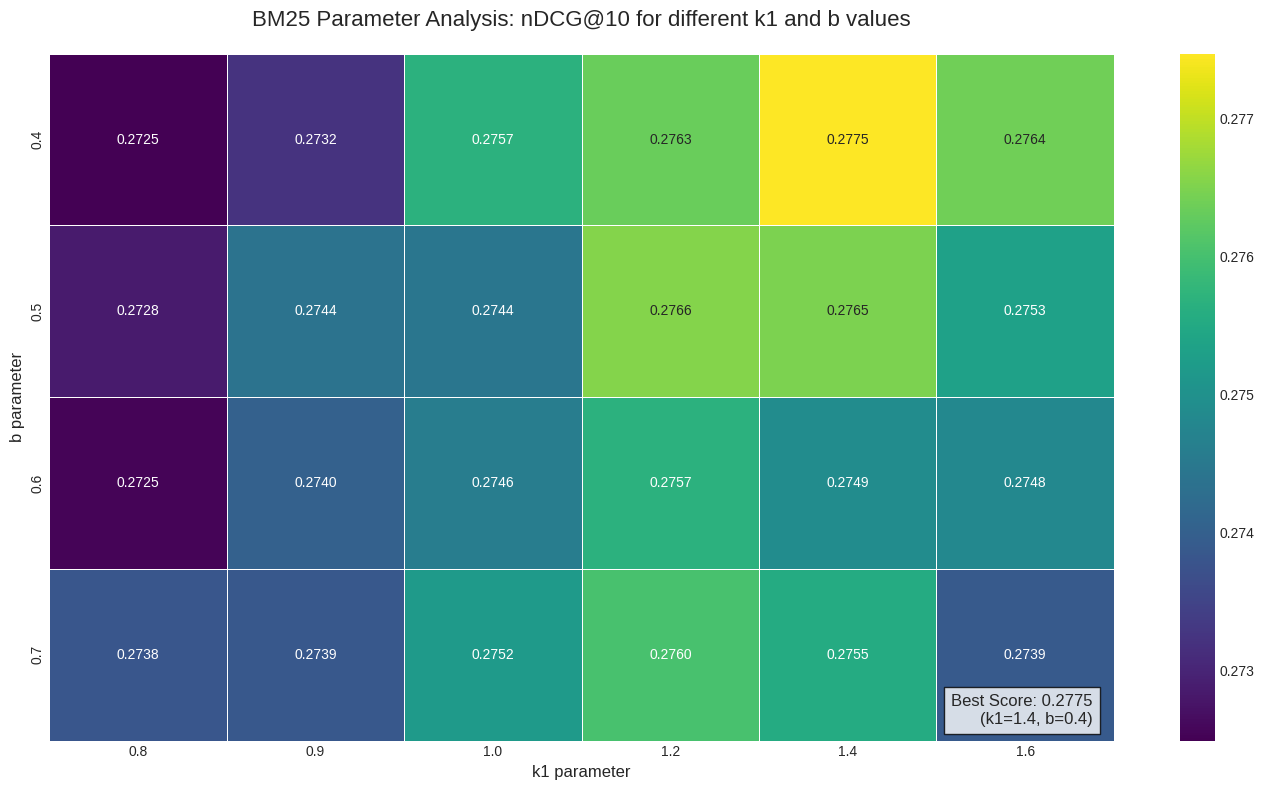

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bm25_heatmap(csv_path):
    """
    Loads BM25 grid search results from a CSV and plots a heatmap
    of nDCG@10 scores against k1 and b parameters.

    Args:
        csv_path (str): The path to the input CSV file.
    """
    # Load data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: The file '{csv_path}' was not found.")
        print("Please make sure you have uploaded the file to your Colab session.")
        return

    print(df.head())
    print("\n")

    # Find the best parameters
    best_params = df.loc[df['nDCG@10'].idxmax()]
    best_k1 = best_params['k1']
    best_b = best_params['b']
    best_score = best_params['nDCG@10']

    print(f"Best nDCG@10 score of {best_score:.4f} was achieved with k1={best_k1} and b={best_b}")
    print("\n")

    pivot_df = df.pivot_table(index='b', columns='k1', values='nDCG@10')

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 8)) # Create a figure and axes for the plot

    # Create the heatmap.
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".4f",
        cmap='viridis',
        linewidths=.5,
        ax=ax
    )

    ax.set_title('BM25 Parameter Analysis: nDCG@10 for different k1 and b values', fontsize=16, pad=20)
    ax.set_xlabel('k1 parameter', fontsize=12)
    ax.set_ylabel('b parameter', fontsize=12)
    plt.text(0.98, 0.02, f'Best Score: {best_score:.4f}\n(k1={best_k1}, b={best_b})',
             fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, pad=5),
             ha='right', va='bottom', transform=ax.transAxes)


    plt.tight_layout()
    plt.show()

csv_file_path = 'nfcorpus_dev_bm25_grid.csv'
plot_bm25_heatmap(csv_file_path)

# PCA

In [ ]:
# save as make_bundle_with_labels.py
import json

TEST, CORPUS, QUERY, OUT = "test.tsv", "corpus.jsonl", "queries.jsonl", "bundle.json"

# read first qid block + collect 3 unrelated doc ids from following qids
first_qid, rel_docs, unrelated = None, [], []
with open(TEST, encoding="utf-8") as f:
    for ln in f:
        ln = ln.strip()
        if not ln: continue
        a = ln.split("\t")
        if a[0].lower() in {"qid","query-id","query_id"}:
            continue
        qid, pid, *rest = a + ["0"]*(3-len(a))
        score = int(rest[0])
        if first_qid is None:
            first_qid = qid
        if qid == first_qid:
            rel_docs.append((pid, score))
        elif len(unrelated) < 3:
            unrelated.append(pid)
        if first_qid and len(unrelated) == 3 and qid != first_qid and rel_docs:
            pass

# dedupe unrelated (avoid overlap with related)
rel_pids = {pid for pid, _ in rel_docs}
unrelated = [pid for pid in unrelated if pid not in rel_pids][:3]

# look up query text
qid2text = {}
with open(QUERY, encoding="utf-8") as f:
    for ln in f:
        if not ln.strip(): continue
        o = json.loads(ln)
        qid2text[o["_id"]] = o.get("text", "")
query_text = qid2text.get(first_qid, "")

# fetch needed docs from corpus
need = rel_pids | set(unrelated)
pid2text = {}
with open(CORPUS, encoding="utf-8") as f:
    for ln in f:
        if len(pid2text) == len(need): break
        if not ln.strip(): continue
        o = json.loads(ln)
        pid = o.get("_id")
        if pid in need:
            title = (o.get("title") or "").strip()
            text  = (o.get("text")  or "").strip()
            pid2text[pid] = (title+"\n"+text).strip() if title else text

# build labeled docs (+ add unrelated as red)
def label(score): return "green" if score==2 else ("yellow" if score==1 else "red")

docs = [{"doc_id": pid, "text": pid2text.get(pid, ""), "label": label(sc)} for pid, sc in rel_docs]
docs += [{"doc_id": pid, "text": pid2text.get(pid, ""), "label": "red"} for pid in unrelated]

bundle = {"query_id": first_qid, "query": query_text, "documents": docs}

with open(OUT, "w", encoding="utf-8") as f:
    json.dump(bundle, f, ensure_ascii=False, indent=2)

print(f"Saved {OUT} for query {first_qid} with {len(docs)} docs "
      f"({len(rel_docs)} related + {len(unrelated)} unrelated).")


Saved bundle.json for query PLAIN-2 with 27 docs (24 related + 3 unrelated).


In [ ]:
# save as encode_bundle_bge.py
# pip install -U sentence-transformers torch
import json, numpy as np, torch
from sentence_transformers import SentenceTransformer

BUNDLE = "bundle.json"
MODEL  = "/content/output/weights/runs/bge-base-nfcorpus"
OUT_NPY = "embeddings.npy"       # matrix: [1 + #docs, dim]
OUT_TXT = "embedding_order.txt"  # lines describing each row

# load bundle
b = json.load(open(BUNDLE, encoding="utf-8"))
query = b["query"]
docs  = b["documents"]

# stable order: query, then green, then yellow, then red (preserve JSON order within each label)
prio = {"green": 0, "yellow": 1, "red": 2}
ordered = sorted(list(enumerate(docs)), key=lambda x: (prio.get(x[1]["label"], 2), x[0]))
ordered_docs = [d for _, d in ordered]

# texts to encode (apply BGE query instruction to the query)
def qfmt(x): return x
texts = [qfmt(query)] + [d["text"] for d in ordered_docs]

# load model & encode
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer(MODEL, device=device)
model.normalize_embeddings = True  # BGE works best with normalized embeddings

with torch.inference_mode():
    embs = model.encode(texts, batch_size=64, convert_to_tensor=True)  # shape: [N, dim]

# save outputs
np.save(OUT_NPY, embs.cpu().numpy())
with open(OUT_TXT, "w", encoding="utf-8") as f:
    f.write("0\tQUERY\n")
    for i, d in enumerate(ordered_docs, start=1):
        f.write(f"{i}\t{d['doc_id']}\t{d.get('label','')}\n")

print(f"Saved matrix to {OUT_NPY} with shape {tuple(embs.shape)}")
print(f"Row order written to {OUT_TXT}")


In [ ]:
# save as pca2_from_embeddings.py
# pip install -U numpy scikit-learn torch
import os, numpy as np

EMB = "embeddings.npy" if os.path.exists("embeddings.npy") else "embedding.npy"  # try both
OUT = "embeddings_pca2.npy"

# --- load matrix (supports np.save or torch.save formats)
try:
    X = np.load(EMB)
except Exception:
    import torch
    X = torch.load(EMB)
    if hasattr(X, "detach"): X = X.detach().cpu().numpy()
    elif hasattr(X, "numpy"): X = X.cpu().numpy()

X = np.asarray(X)
assert X.ndim == 2, f"expected 2D array, got shape {X.shape}"

# --- PCA to k=2
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)  # shape: [n_samples, 2]

# --- save & print
np.save(OUT, X2)
print(X2)                 # returns the matrix
print(f"Saved 2D matrix to {OUT} with shape {X2.shape}")


[[ 0.38917452  0.09900288]
 [-0.01625215  0.1679391 ]
 [ 0.2850023   0.01415831]
 [ 0.26620007  0.04760503]
 [-0.06049409  0.19363302]
 [ 0.24366753  0.00696018]
 [ 0.28649595  0.05519587]
 [-0.15454526 -0.03477413]
 [ 0.20890215 -0.0937524 ]
 [ 0.05425238  0.03211068]
 [-0.08828377  0.16511257]
 [-0.10616313  0.3022851 ]
 [ 0.15244891  0.14819664]
 [-0.0157589   0.21921892]
 [-0.0693956   0.17449504]
 [-0.00816078  0.29858252]
 [-0.2271685  -0.10618675]
 [-0.2307594  -0.12937333]
 [-0.34458223 -0.18020427]
 [-0.28031588 -0.14755538]
 [ 0.03730852 -0.1371645 ]
 [-0.09487755 -0.12169252]
 [ 0.16799088 -0.3493944 ]
 [ 0.18025419 -0.34479672]
 [ 0.12743334 -0.33975175]
 [-0.1533742   0.12798877]
 [-0.29672065  0.02165855]
 [-0.25227845 -0.08949704]]
Saved 2D matrix to embeddings_pca2.npy with shape (28, 2)


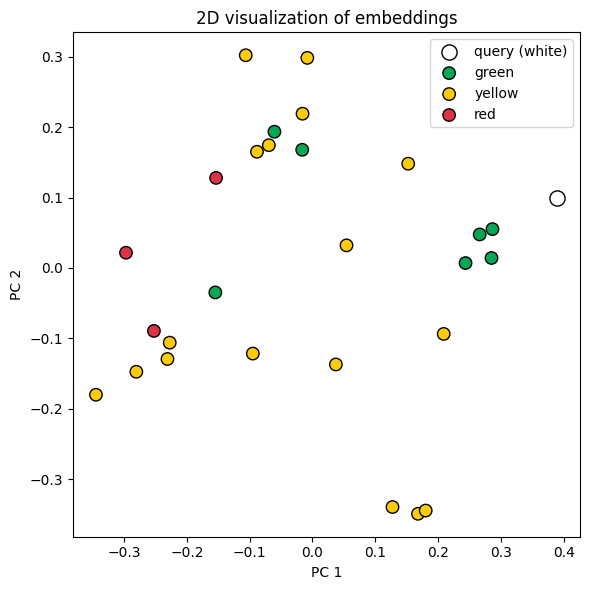

Plotted 28 points from embeddings_pca2.npy -> embeddings_2d_plot.png


In [ ]:
# save as plot_2d_embeddings.py
# pip install -U numpy matplotlib

import os, json, numpy as np
import matplotlib.pyplot as plt

# --- files (tries common names) ---
EMB2 = next((p for p in ["embeddings2.npy", "embeddings_pca2.npy"] if os.path.exists(p)), None)
ORDER_TXT = "embedding_order.txt"   # from the earlier step

if EMB2 is None:
    raise FileNotFoundError("Could not find embeddings2.npy or embeddings_pca2.npy")

# --- load 2D coords ---
X2 = np.load(EMB2)  # shape: [N, 2]
assert X2.ndim == 2 and X2.shape[1] == 2, f"Expecting 2D coords, got {X2.shape}"

# --- build labels (query first, then from order file) ---
labels = []
ids = []

with open(ORDER_TXT, encoding="utf-8") as f:
    lines = [ln.strip() for ln in f if ln.strip()]

# First line is the query marker: "0\tQUERY"
if not lines or "QUERY" not in lines[0].upper():
    raise RuntimeError(f"{ORDER_TXT} malformed: first line should describe the query (e.g., '0\\tQUERY').")

labels.append("white")  # query color
ids.append("QUERY")

# Next lines: "<row_idx>\t<doc_id>\t<label>"
for ln in lines[1:]:
    parts = ln.split("\t")
    # tolerate missing label column
    doc_id = parts[1] if len(parts) > 1 else f"doc_{len(ids)}"
    lab    = parts[2].lower() if len(parts) > 2 else "red"
    # normalize to expected set
    if lab not in {"green","yellow","red"}:
        lab = "red"
    labels.append(lab)
    ids.append(doc_id)

assert len(labels) == X2.shape[0], f"Label count {len(labels)} != rows {X2.shape[0]}.\nCheck {ORDER_TXT} matches the embedding rows."

# --- color map ---
cmap = {"white":"#ffffff", "green":"#00aa55", "yellow":"#ffcc00", "red":"#dd3344"}
colors = [cmap.get(l, "#000000") for l in labels]

# --- plot ---
plt.figure(figsize=(6, 6))
plt.scatter(X2[0:1,0], X2[0:1,1], c=[colors[0]], edgecolors="black", s=120, label="query (white)")
# plot docs by color
for name in ["green","yellow","red"]:
    idx = [i for i,l in enumerate(labels) if l == name]
    if idx:
        plt.scatter(X2[idx,0], X2[idx,1], c=[cmap[name]]*len(idx), edgecolors="black", s=80, label=name)

plt.title("2D visualization of embeddings")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.savefig("embeddings_2d_plot.png", dpi=160)
plt.show()

print(f"Plotted {X2.shape[0]} points from {EMB2} -> embeddings_2d_plot.png")


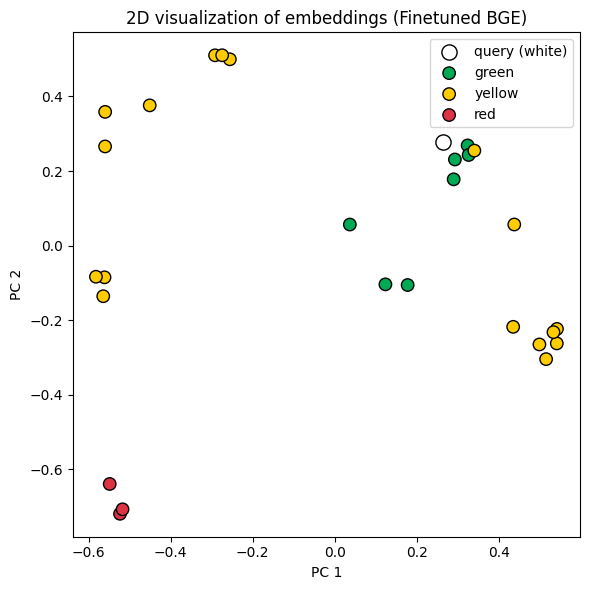

Plotted 28 points from embeddings_pca2.npy -> embeddings_2d_plot.png


In [ ]:
# save as plot_2d_embeddings.py
# pip install -U numpy matplotlib

import os, json, numpy as np
import matplotlib.pyplot as plt

# --- files (tries common names) ---
EMB2 = next((p for p in ["embeddings2.npy", "embeddings_pca2.npy"] if os.path.exists(p)), None)
ORDER_TXT = "embedding_order.txt"   # from the earlier step

if EMB2 is None:
    raise FileNotFoundError("Could not find embeddings2.npy or embeddings_pca2.npy")

# --- load 2D coords ---
X2 = np.load(EMB2)  # shape: [N, 2]
assert X2.ndim == 2 and X2.shape[1] == 2, f"Expecting 2D coords, got {X2.shape}"

# --- build labels (query first, then from order file) ---
labels = []
ids = []

with open(ORDER_TXT, encoding="utf-8") as f:
    lines = [ln.strip() for ln in f if ln.strip()]

# First line is the query marker: "0\tQUERY"
if not lines or "QUERY" not in lines[0].upper():
    raise RuntimeError(f"{ORDER_TXT} malformed: first line should describe the query (e.g., '0\\tQUERY').")

labels.append("white")  # query color
ids.append("QUERY")

# Next lines: "<row_idx>\t<doc_id>\t<label>"
for ln in lines[1:]:
    parts = ln.split("\t")
    # tolerate missing label column
    doc_id = parts[1] if len(parts) > 1 else f"doc_{len(ids)}"
    lab    = parts[2].lower() if len(parts) > 2 else "red"
    # normalize to expected set
    if lab not in {"green","yellow","red"}:
        lab = "red"
    labels.append(lab)
    ids.append(doc_id)

assert len(labels) == X2.shape[0], f"Label count {len(labels)} != rows {X2.shape[0]}.\nCheck {ORDER_TXT} matches the embedding rows."

# --- color map ---
cmap = {"white":"#ffffff", "green":"#00aa55", "yellow":"#ffcc00", "red":"#dd3344"}
colors = [cmap.get(l, "#000000") for l in labels]

# --- plot ---
plt.figure(figsize=(6, 6))
plt.scatter(X2[0:1,0], X2[0:1,1], c=[colors[0]], edgecolors="black", s=120, label="query (white)")
# plot docs by color
for name in ["green","yellow","red"]:
    idx = [i for i,l in enumerate(labels) if l == name]
    if idx:
        plt.scatter(X2[idx,0], X2[idx,1], c=[cmap[name]]*len(idx), edgecolors="black", s=80, label=name)

plt.title("2D visualization of embeddings (Finetuned BGE)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.savefig("embeddings_2d_plot.png", dpi=160)
plt.show()

print(f"Plotted {X2.shape[0]} points from {EMB2} -> embeddings_2d_plot.png")


# Hybrid Scoring - Alpha values

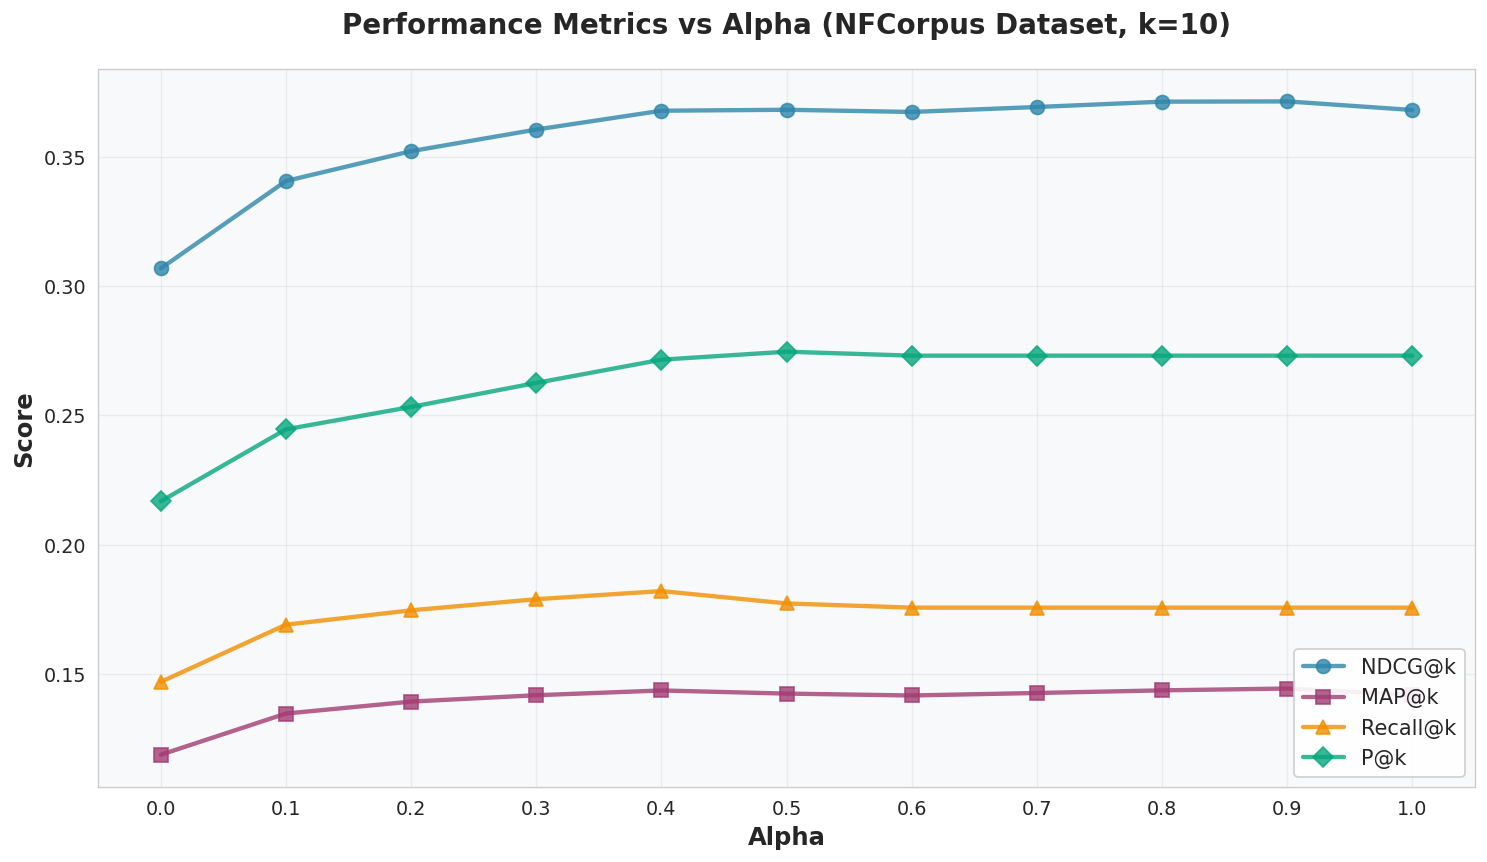

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'alpha': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'NDCG@k': [0.30682, 0.34063, 0.35217, 0.36054, 0.36782, 0.36819, 0.36734, 0.36926, 0.37132, 0.37143, 0.3681],
    'MAP@k': [0.1187, 0.13464, 0.13926, 0.14172, 0.14356, 0.14235, 0.14162, 0.14259, 0.1436, 0.14431, 0.14183],
    'Recall@k': [0.14688, 0.16901, 0.17456, 0.17887, 0.18201, 0.17722, 0.1756, 0.1756, 0.1756, 0.1756, 0.1756],
    'P@k': [0.21672, 0.24458, 0.25325, 0.26254, 0.27152, 0.27461, 0.27307, 0.27307, 0.27307, 0.27307, 0.27307]
}

df = pd.DataFrame(data)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7), dpi=125)

# Plot
metrics = ['NDCG@k', 'MAP@k', 'Recall@k', 'P@k']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
markers = ['o', 's', '^', 'D']

for metric, color, marker in zip(metrics, colors, markers):
    plt.plot(df['alpha'], df[metric], marker=marker, linewidth=2.5,
             markersize=8, label=metric, color=color, alpha=0.8)

plt.xlabel('Alpha', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Performance Metrics vs Alpha (NFCorpus Dataset, k=10)',
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.xticks(df['alpha'], fontsize=11)
plt.yticks(fontsize=11)

ax = plt.gca()
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()